In [1]:
import re
import nltk
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF, TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score, silhouette_score
from sklearn.metrics.pairwise import euclidean_distances
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

# Download resources required by the preprocessing pipeline.
for resource in [
    "punkt_tab",
    "stopwords",
    "wordnet",
    "omw-1.4",
    "averaged_perceptron_tagger_eng",
]:
    nltk.download(resource)


[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/maryam/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/maryam/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/maryam/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/maryam/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/maryam/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


# loading the data

In [2]:
def load_newsgroup_data(categories=None, subset="train"):
    """Load the requested subset of the 20 Newsgroups dataset."""
    valid_subsets = {"train", "test", "all"}
    if subset not in valid_subsets:
        raise ValueError(f"subset must be one of {sorted(valid_subsets)}, got {subset!r}")

    return fetch_20newsgroups(
        categories=categories,
        subset=subset,
        remove=("headers", "footers", "quotes"),
    )

categories = [
    "comp.graphics",
    "talk.politics.guns",
    "alt.atheism",
    "sci.med",
    "sci.space",
]

# Use train + test because the goal is unsupervised clustering rather than
# predictive evaluation on a held-out test split.
data = load_newsgroup_data(categories, subset="all")
print(f"Loaded {len(data.data)} documents from {len(categories)} categories.")


Loaded 4659 documents from 5 categories.


# preprocessing the text

In [3]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    """Convert Penn Treebank POS tags to WordNet POS tags."""
    if tag.startswith("J"):
        return wordnet.ADJ
    if tag.startswith("V"):
        return wordnet.VERB
    if tag.startswith("N"):
        return wordnet.NOUN
    if tag.startswith("R"):
        return wordnet.ADV
    return wordnet.NOUN

def preprocess_text(text, lemmatization=True):
    """Lowercase, remove numbers/stopwords, tokenize, and optionally lemmatize."""
    text = re.sub(r"\d+", "", text.lower())
    tokens = word_tokenize(text)

    if lemmatization:
        tagged_tokens = pos_tag(tokens)
        filtered_tokens = [
            lemmatizer.lemmatize(word, pos=get_wordnet_pos(tag))
            for word, tag in tagged_tokens
            if word.isalpha() and word not in stop_words
        ]
    else:
        filtered_tokens = [
            word for word in tokens
            if word.isalpha() and word not in stop_words
        ]

    return " ".join(filtered_tokens)

processed_data = [preprocess_text(doc) for doc in data.data]

print("Sample original document (first 150 chars):")
print(f"{data.data[0][:150]}...")
print("\nSample processed document (lemmatized):")
print(processed_data[0])
print("\nPreprocessing complete.")


Sample original document (first 150 chars):


Early to mid June.


If they think the public wants to see it they will carry it. Why not
write them and ask? You can reach them at:


             ...

Sample processed document (lemmatized):
early mid june think public want see carry write ask reach f national news medium abc world news tonight face nation west th street cbs news new york ny street nw washington dc associate press good morning america rockefeller plaza abc news new york ny broadway national desk new york ny foreign desk washington bureau larry king live tv cbs even news cnn th street massachusetts avenue nw new york ny washington dc cbs morning larry king show radio th street mutual broadcast new york ny jefferson davis highway arlington va christian science monitor csm publishing society los angeles time one norway street square boston los angeles ca cnn newshour one cnn center box box washington dc atlanta ga newshour cnn washington bureau th street massachusetts avenue

# TF-IDF Explanation

TF-IDF stands for **Term Frequency-Inverse Document Frequency**. It's a numerical statistic used to reflect how important a word is to a document within a collection or corpus. It combines two metrics:

*   **Term Frequency (TF):**
    *   Measures how frequently a term appears in a *specific document*.
    *   Calculation: Often calculated as (Number of times term *t* appears in document *d*) / (Total number of terms in document *d*).
    *   Intuition: Words that appear more often in a document are likely more relevant to *that* document's content.

*   **Inverse Document Frequency (IDF):**
    *   Measures how important a term is across the *entire corpus*. It diminishes the weight of terms that occur very frequently across many documents (like common words, even if not stopwords) and increases the weight of terms that occur rarely.
    *   Calculation: Typically calculated as log( (Total number of documents in corpus) / (1 + Number of documents containing term *t*) ). The `+1` (smoothing) prevents division by zero if a term isn't in any document (though this shouldn't happen with standard vectorizers) and dampens the effect for terms present in all documents.
    *   Intuition: Rare words are often more informative or discriminative than common words found everywhere.

*   **TF-IDF Score:**
    *   The final score for a term *t* in a document *d* is the product of its TF and IDF values:
        `TF-IDF(t, d) = TF(t, d) * IDF(t, Corpus)`
    *   Interpretation: Words with a high TF-IDF score are frequent within a *particular* document but relatively rare across the *entire* set of documents. This makes them strong indicators of the topic or content of that specific document.

## building tf-idf matrix

In [4]:
vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, stop_words=None)
# max_df=0.95: ignore terms that appear in more than 95% of the documents
# min_df=2: ignore terms that appear in less than 2 documents

tfidf_matrix = vectorizer.fit_transform(processed_data)
feature_names = vectorizer.get_feature_names_out()

print(f"   TF-IDF matrix created with shape: {tfidf_matrix.shape}")
print(f"   (Documents: {tfidf_matrix.shape[0]}, Unique Terms (Features): {tfidf_matrix.shape[1]})")
print(f"   Sample feature names: {feature_names[50:60]}...")


   TF-IDF matrix created with shape: (4659, 15360)
   (Documents: 4659, Unique Terms (Features): 15360)
   Sample feature names: ['absorption' 'abstact' 'abstract' 'abstraction' 'abstruse' 'absurd'
 'absurdity' 'abundant' 'abundantly' 'abuse']...


# clustering using NMF

In [5]:
n_clusters = len(categories)

def evaluate_clustering(labels):
    """Compute external and internal clustering metrics."""
    return {
        "ari": adjusted_rand_score(data.target, labels),
        "ami": adjusted_mutual_info_score(data.target, labels),
        "silhouette_euclidean": silhouette_score(
            tfidf_matrix, labels, metric="euclidean"
        ),
        "silhouette_cosine": silhouette_score(
            tfidf_matrix, labels, metric="cosine"
        ),
    }

nmf_model = NMF(
    n_components=n_clusters,
    init="nndsvda",
    random_state=42,
    max_iter=300,
    solver="cd",
)

W = nmf_model.fit_transform(tfidf_matrix)
nmf_clusters = np.argmax(W, axis=1)
nmf_metrics = evaluate_clustering(nmf_clusters)

print(f"NMF clustering complete: {n_clusters} clusters")
print(f"ARI:                  {nmf_metrics['ari']:.4f}")
print(f"AMI:                  {nmf_metrics['ami']:.4f}")
print(f"Silhouette Euclidean: {nmf_metrics['silhouette_euclidean']:.4f}")
print(f"Silhouette Cosine:    {nmf_metrics['silhouette_cosine']:.4f}")


/Users/maryam/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/Users/maryam/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/Users/maryam/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat


NMF clustering complete: 5 clusters
ARI:                  0.3501
AMI:                  0.4093
Silhouette Euclidean: 0.0059
Silhouette Cosine:    0.0109


/Users/maryam/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/Users/maryam/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/Users/maryam/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat


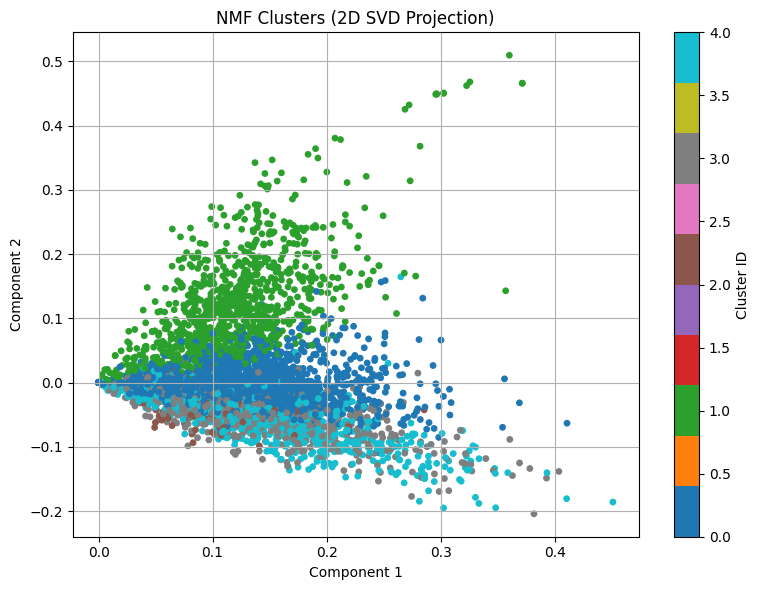

In [6]:
# Compute one common 2D projection and reuse it for all clustering plots.
svd = TruncatedSVD(n_components=2, random_state=42)
reduced_tfidf = svd.fit_transform(tfidf_matrix)

plt.figure(figsize=(8, 6))
plt.scatter(
    reduced_tfidf[:, 0],
    reduced_tfidf[:, 1],
    c=nmf_clusters,
    cmap="tab10",
    s=15,
)
plt.title("NMF Clusters (2D SVD Projection)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label="Cluster ID")
plt.grid(True)
plt.tight_layout()
plt.show()


In [7]:
tfidf_matrix.shape

(4659, 15360)

In [8]:
n_top_words = 10
for topic_idx, topic in enumerate(nmf_model.components_):
    top_indices = topic.argsort()[:-n_top_words - 1:-1]
    top_words = [feature_names[i] for i in top_indices]
    print(f" Topic {topic_idx}: {' | '.join(top_words)}")


 Topic 0: would | space | get | one | like | go | think | time | use | know
 Topic 1: file | image | format | thanks | program | graphic | please | color | know | anyone
 Topic 2: bank | geb | shameful | njxp | chastity | intellect | skepticism | surrender | gordon | soon
 Topic 3: god | say | believe | atheist | belief | religion | one | atheism | exist | think
 Topic 4: gun | people | right | fire | law | would | weapon | fbi | crime | government


### Topic-word interpretation note

One NMF component contains residual signature-like or corpus-specific tokens such as `geb` and `njxp`. The dataset loader removes headers, footers, and quoted text, but those heuristics do not eliminate every signature artifact. Treat this as a preprocessing limitation rather than assigning that component a confident semantic label.


# implementing custom K-means

In [9]:
def custom_kmeans(
    X,
    n_clusters,
    max_iter=300,
    tol=1e-6,
    random_state=None,
    initial_centroids=None,
    verbose=True,
):
    """Lloyd-style K-Means with local random-state handling."""
    rng = np.random.default_rng(random_state)
    n_samples, n_features = X.shape

    if initial_centroids is None:
        initial_indices = rng.choice(n_samples, n_clusters, replace=False)
        if isinstance(X, np.ndarray):
            centroids = X[initial_indices].astype(float, copy=True)
        else:
            centroids = X[initial_indices].toarray().astype(float, copy=True)
    else:
        centroids = np.asarray(initial_centroids, dtype=float).copy()
        expected_shape = (n_clusters, n_features)
        if centroids.shape != expected_shape:
            raise ValueError(
                f"initial_centroids must have shape {expected_shape}, got {centroids.shape}"
            )

    for iteration in range(max_iter):
        distances = euclidean_distances(X, centroids)
        labels = np.argmin(distances, axis=1)

        new_centroids = np.empty_like(centroids)
        for cluster_id in range(n_clusters):
            member_indices = np.flatnonzero(labels == cluster_id)

            if member_indices.size:
                if isinstance(X, np.ndarray):
                    new_centroids[cluster_id] = X[member_indices].mean(axis=0)
                else:
                    new_centroids[cluster_id] = np.asarray(
                        X[member_indices].mean(axis=0)
                    ).ravel()
            else:
                random_index = int(rng.integers(n_samples))
                if isinstance(X, np.ndarray):
                    new_centroids[cluster_id] = X[random_index]
                else:
                    new_centroids[cluster_id] = X[random_index].toarray().ravel()

                if verbose:
                    print(
                        f"Warning: cluster {cluster_id} became empty; "
                        "reinitialized its centroid."
                    )

        centroid_shift = np.linalg.norm(new_centroids - centroids, ord="fro")
        centroids = new_centroids

        if centroid_shift < tol:
            if verbose:
                print(
                    f"Custom K-Means converged after {iteration + 1} iterations "
                    f"(centroid shift={centroid_shift:.3e})."
                )
            break
    else:
        if verbose:
            print(f"Custom K-Means reached max_iter={max_iter}.")

    # Final assignment guarantees that returned labels match the final centroids.
    final_distances = euclidean_distances(X, centroids)
    labels = np.argmin(final_distances, axis=1)
    return centroids, labels

custom_centroids, custom_kmeans_clusters = custom_kmeans(
    tfidf_matrix,
    n_clusters=n_clusters,
    random_state=42,
    max_iter=300,
)

custom_metrics = evaluate_clustering(custom_kmeans_clusters)

print("\nCustom K-Means evaluation")
print(f"ARI:                  {custom_metrics['ari']:.4f}")
print(f"AMI:                  {custom_metrics['ami']:.4f}")
print(f"Silhouette Euclidean: {custom_metrics['silhouette_euclidean']:.4f}")
print(f"Silhouette Cosine:    {custom_metrics['silhouette_cosine']:.4f}")


Custom K-Means converged after 35 iterations (centroid shift=0.000e+00).

Custom K-Means evaluation
ARI:                  0.1935
AMI:                  0.2922
Silhouette Euclidean: 0.0062
Silhouette Cosine:    0.0043


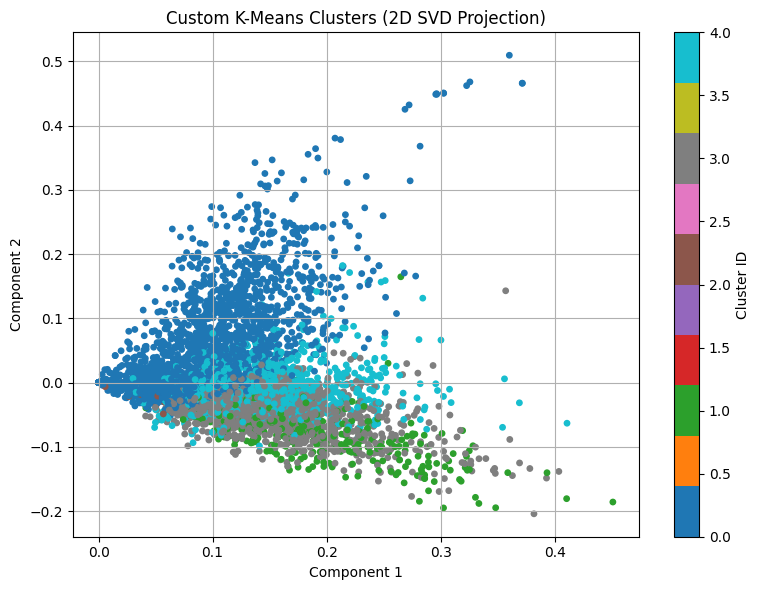

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(
    reduced_tfidf[:, 0],
    reduced_tfidf[:, 1],
    c=custom_kmeans_clusters,
    cmap="tab10",
    s=15,
)
plt.title("Custom K-Means Clusters (2D SVD Projection)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label="Cluster ID")
plt.grid(True)
plt.tight_layout()
plt.show()


In [11]:
n_top_words = 10
for cluster_idx, centroid in enumerate(custom_centroids):
    top_indices = centroid.argsort()[:-n_top_words - 1:-1]
    top_words = [feature_names[i] for i in top_indices]
    print(f"Custom Cluster {cluster_idx}: {' | '.join(top_words)}")


Custom Cluster 0: file | thanks | image | know | use | would | anyone | please | look | graphic
Custom Cluster 1: gun | law | weapon | right | people | would | crime | firearm | criminal | state
Custom Cluster 2: feustel | nmyi | dave | waco | irs | tax | federal | propane | tank | tread
Custom Cluster 3: say | think | one | god | would | people | make | believe | get | see
Custom Cluster 4: space | would | get | one | go | year | launch | use | time | problem


# comparing sklearn implemntation with custom one

In [12]:
# This is an algorithm/configuration comparison: scikit-learn uses K-Means++
# here, while the custom implementation starts from random documents.
kmeans_sklearn = KMeans(
    n_clusters=n_clusters,
    init="k-means++",
    n_init="auto",
    random_state=42,
    max_iter=300,
)

sklearn_kmeans_clusters = kmeans_sklearn.fit_predict(tfidf_matrix)
sklearn_metrics = evaluate_clustering(sklearn_kmeans_clusters)

print("Scikit-learn K-Means evaluation")
print(f"ARI:                  {sklearn_metrics['ari']:.4f}")
print(f"AMI:                  {sklearn_metrics['ami']:.4f}")
print(f"Silhouette Euclidean: {sklearn_metrics['silhouette_euclidean']:.4f}")
print(f"Silhouette Cosine:    {sklearn_metrics['silhouette_cosine']:.4f}")

comparison_ari = adjusted_rand_score(custom_kmeans_clusters, sklearn_kmeans_clusters)
comparison_ami = adjusted_mutual_info_score(custom_kmeans_clusters, sklearn_kmeans_clusters)

print("\nAgreement between the two single-run K-Means outputs")
print(f"ARI: {comparison_ari:.4f}")
print(f"AMI: {comparison_ami:.4f}")
print("Note: this is not a pure implementation validation because initialization differs.")


/Users/maryam/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/maryam/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/maryam/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight


Scikit-learn K-Means evaluation
ARI:                  0.1638
AMI:                  0.3732
Silhouette Euclidean: 0.0083
Silhouette Cosine:    0.0036

Agreement between the two single-run K-Means outputs
ARI: 0.1456
AMI: 0.3534
Note: this is not a pure implementation validation because initialization differs.


## Controlled validation across multiple seeds

The single-run comparison above uses different initialization strategies, so it should not be treated as pure implementation validation. The experiment below gives the custom implementation and scikit-learn **the same initial centroids** for each seed and repeats the comparison across 10 seeds. It reports mean ± standard deviation for ARI/AMI and the agreement between the two implementations.


In [13]:
seeds = range(10)

custom_ari_scores = []
custom_ami_scores = []
sklearn_ari_scores = []
sklearn_ami_scores = []
agreement_ari_scores = []
agreement_ami_scores = []

for seed in seeds:
    seed_rng = np.random.default_rng(seed)
    init_indices = seed_rng.choice(
        tfidf_matrix.shape[0], n_clusters, replace=False
    )
    shared_initial_centroids = tfidf_matrix[init_indices].toarray()

    _, custom_labels = custom_kmeans(
        tfidf_matrix,
        n_clusters=n_clusters,
        random_state=seed,
        initial_centroids=shared_initial_centroids,
        max_iter=300,
        verbose=False,
    )

    controlled_sklearn = KMeans(
        n_clusters=n_clusters,
        init=shared_initial_centroids,
        n_init=1,
        random_state=seed,
        max_iter=300,
        algorithm="lloyd",
    )
    sklearn_labels = controlled_sklearn.fit_predict(tfidf_matrix)

    custom_ari_scores.append(adjusted_rand_score(data.target, custom_labels))
    custom_ami_scores.append(adjusted_mutual_info_score(data.target, custom_labels))
    sklearn_ari_scores.append(adjusted_rand_score(data.target, sklearn_labels))
    sklearn_ami_scores.append(adjusted_mutual_info_score(data.target, sklearn_labels))
    agreement_ari_scores.append(adjusted_rand_score(custom_labels, sklearn_labels))
    agreement_ami_scores.append(adjusted_mutual_info_score(custom_labels, sklearn_labels))

def mean_std(values):
    values = np.asarray(values, dtype=float)
    return values.mean(), values.std(ddof=1)

print("Controlled same-initialization comparison across 10 seeds")
for name, values in [
    ("Custom ARI", custom_ari_scores),
    ("Custom AMI", custom_ami_scores),
    ("Scikit-learn ARI", sklearn_ari_scores),
    ("Scikit-learn AMI", sklearn_ami_scores),
    ("Custom vs sklearn ARI", agreement_ari_scores),
    ("Custom vs sklearn AMI", agreement_ami_scores),
]:
    mean_value, std_value = mean_std(values)
    print(f"{name:24s}: {mean_value:.4f} ± {std_value:.4f}")


Controlled same-initialization comparison across 10 seeds
Custom ARI              : 0.0975 ± 0.0699
Custom AMI              : 0.2049 ± 0.1431
Scikit-learn ARI        : 0.1026 ± 0.0634
Scikit-learn AMI        : 0.2252 ± 0.1269
Custom vs sklearn ARI   : 0.7557 ± 0.3770
Custom vs sklearn AMI   : 0.7689 ± 0.3465


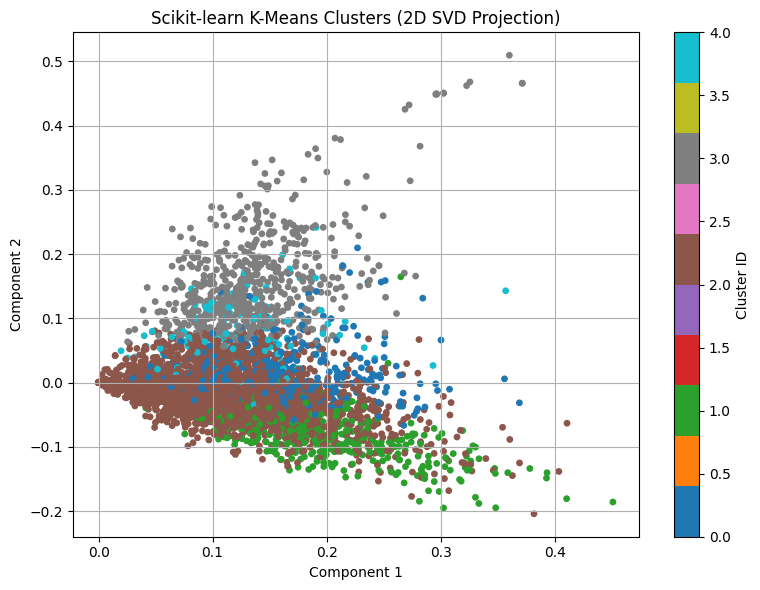

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(
    reduced_tfidf[:, 0],
    reduced_tfidf[:, 1],
    c=sklearn_kmeans_clusters,
    cmap="tab10",
    s=15,
)
plt.title("Scikit-learn K-Means Clusters (2D SVD Projection)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label="Cluster ID")
plt.grid(True)
plt.tight_layout()
plt.show()


# Why are the Silhouette Scores Low for TF-IDF Text Clustering?

Silhouette values close to zero indicate that samples are, on average, only weakly separated from neighboring clusters under the selected distance metric. For sparse, high-dimensional TF-IDF text representations, that result is not unusual.

For each sample, the Silhouette coefficient compares:

- **a**: its mean distance to the other samples in its own cluster, and
- **b**: its mean distance to the samples in the nearest other cluster.

The coefficient is `(b - a) / max(a, b)`. It does **not** use distance to a cluster centroid as its definition.

Several factors can produce low values here:

1. **High dimensionality.** Distances become less discriminative as dimensionality grows.
2. **Sparsity.** Documents contain only a small fraction of the vocabulary, and topical similarity is not always well represented by raw Euclidean geometry. Shared zero entries themselves contribute zero to Euclidean distance; the issue is the geometry of sparse high-dimensional vectors as a whole.
3. **Topic overlap.** Newsgroup categories share vocabulary and can have fuzzy semantic boundaries.
4. **K-Means assumptions.** Standard K-Means optimizes squared Euclidean distance and favors roughly convex clusters, which need not match the structure of text topics.
5. **NMF objectives.** NMF discovers additive latent components; assigning each document to its largest component does not directly optimize Silhouette separation.

For this reason, the notebook reports both **Euclidean** and **cosine** Silhouette scores, together with **ARI** and **AMI** against the known newsgroup labels. These metrics answer different questions and should be interpreted together.


# Evaluation Metrics

Because the 20 Newsgroups category labels are available, this notebook uses both external and internal clustering metrics.

- **Adjusted Rand Index (ARI):** pair-based agreement between predicted clusters and ground-truth categories, corrected for chance. A value of 1 indicates perfect agreement; values near 0 indicate chance-level agreement.
- **Adjusted Mutual Information (AMI):** information-theoretic agreement between the two partitions, adjusted for chance and invariant to cluster-label permutations.
- **Silhouette — Euclidean:** internal cohesion/separation measured with Euclidean distance.
- **Silhouette — Cosine:** the same Silhouette framework using cosine distance, which is often informative for TF-IDF document vectors.

ARI and AMI evaluate agreement with the known labels. Silhouette does not use those labels; it evaluates cohesion and separation in the chosen feature space and distance metric.
